<a href="https://colab.research.google.com/github/Amritpalkaur7/Sign-language-translator/blob/main/sign_language_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls /content/drive/MyDrive

'Colab Notebooks'   SignLanguageProject   sign_language_training.ipynb


In [4]:
!cp -r /content/drive/MyDrive/SignLanguageProject/dataset/asl_alphabet_train /content/

In [22]:
import tensorflow as tf

data_dir = "/content/asl_alphabet_train"

img_size = 64
batch_size = 16

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

class_names = train_data.class_names
print("Classes:", class_names)

Found 28156 files belonging to 29 classes.
Using 22525 files for training.
Found 28156 files belonging to 29 classes.
Using 5631 files for validation.
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


In [25]:
AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_data = val_data.cache().prefetch(buffer_size=AUTOTUNE)

In [26]:
from tensorflow.keras import layers, models

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

In [27]:
model = models.Sequential([
    layers.Input(shape=(64, 64, 3)),

    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(len(class_names), activation='softmax')
])

In [28]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_7 (Sequential)       │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 687,837 (2.62 MB)

 Trainable params: 687,389 (2.62 MB)

 Non-trainable params: 448 (1.75 KB)

In [29]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [30]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=7,
    callbacks=[early_stop]
)

Epoch 1/7
1408/1408 ━━━━━━━━━━━━━━━━━━━━ 33s 13ms/step - accuracy: 0.2524 - loss: 1.9998 - val_accuracy: 0.1847 - val_loss: 2.2669
Epoch 2/7
1408/1408 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.3511 - loss: 1.5403 - val_accuracy: 0.3312 - val_loss: 1.8535
Epoch 3/7
1408/1408 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.4480 - loss: 1.3163 - val_accuracy: 0.3882 - val_loss: 1.5889
Epoch 4/7
1408/1408 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.5321 - loss: 1.1393 - val_accuracy: 0.4853 - val_loss: 2.2909
Epoch 5/7
1408/1408 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.6211 - loss: 0.9476 - val_accuracy: 0.6910 - val_loss: 0.8745
Epoch 6/7
1408/1408 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.6878 - loss: 0.7962 - val_accuracy: 0.6882 - val_loss: 0.8954
Epoch 7/7
1408/1408 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.7331 - loss: 0.6941 - val_accuracy: 0.8027 - val_loss: 0.5004


In [31]:
model.save("/content/drive/MyDrive/SignLanguageProject/model/sign_model.h5")

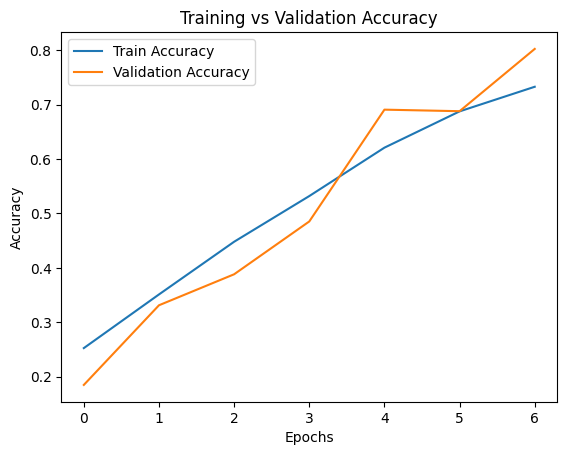

In [32]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()

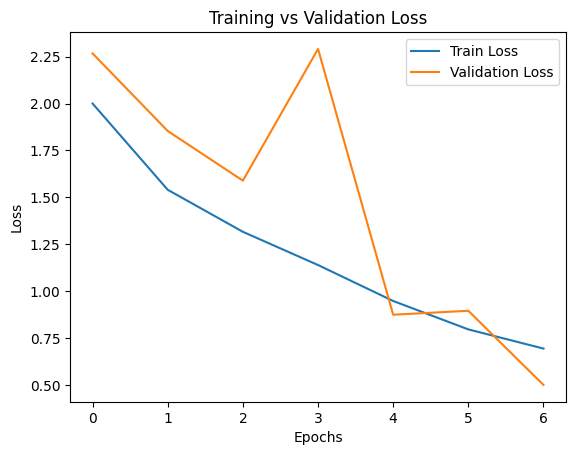

In [33]:
# Loss graph
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()